In [1]:
pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.1 MB/s eta 0:00:00


In [2]:
# =========================================
# CUSTOMER CHURN ANALYSIS PROJECT
# =========================================

# =========================================
# STEP 1 — IMPORT LIBRARIES
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image,
    PageBreak
)

from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import letter

# =========================================
# STEP 2 — LOAD DATASET
# =========================================

df = pd.read_csv("Telecom_Dataset.csv")

# =========================================
# STEP 3 — DATA UNDERSTANDING
# =========================================

print(df.head())

print(df.info())

print(df.isnull().sum())

# =========================================
# STEP 4 — DATA CLEANING
# =========================================

# Convert TotalCharges column
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].mean()
)

# Remove duplicates
df = df.drop_duplicates()

# =========================================
# STEP 5 — BUSINESS ANALYSIS
# =========================================

# Total Customers
total_customers = len(df)

# Churn Customers
churn_customers = len(df[df["Churn"] == "Yes"])

# Retention Rate
retention_rate = round(
    ((total_customers - churn_customers)
    / total_customers) * 100,
    2
)

# Monthly Charges by Churn
monthly_charges = (
    df.groupby("Churn")["MonthlyCharges"]
    .mean()
)

# Contract Analysis
contract_analysis = (
    df.groupby("Contract")["customerID"]
    .count()
)

# Payment Method Analysis
payment_analysis = (
    df.groupby("PaymentMethod")["customerID"]
    .count()
)

# Internet Service Analysis
internet_analysis = (
    df.groupby("InternetService")["customerID"]
    .count()
)

# =========================================
# STEP 6 — CREATE CHARTS
# =========================================

# -----------------------------------------
# CHURN DISTRIBUTION
# -----------------------------------------

plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Churn Distribution")

plt.ylabel("")

plt.tight_layout()

plt.savefig("churn_distribution.png")

plt.close()

# -----------------------------------------
# CONTRACT ANALYSIS
# -----------------------------------------

plt.figure(figsize=(8,5))

contract_analysis.plot(kind="bar")

plt.title("Customers by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig("contract_analysis.png")

plt.close()

# -----------------------------------------
# MONTHLY CHARGES
# -----------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    x=monthly_charges.index,
    y=monthly_charges.values
)

plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig("monthly_charges.png")

plt.close()

# -----------------------------------------
# PAYMENT METHOD ANALYSIS
# -----------------------------------------

plt.figure(figsize=(10,5))

payment_analysis.plot(kind="bar")

plt.title("Customers by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig("payment_analysis.png")

plt.close()

# =========================================
# STEP 7 — CREATE PDF REPORT
# =========================================

doc = SimpleDocTemplate(
    "Customer_Churn_Analysis_Report.pdf",
    pagesize=letter
)

styles = getSampleStyleSheet()

content = []

# =========================================
# COVER PAGE
# =========================================

title = Paragraph(
    "Customer Retention and Churn Analysis",
    styles['Title']
)

content.append(title)

content.append(Spacer(1, 20))

intro = Paragraph(
    """
    This report presents a customer churn analysis
    using telecom customer data to identify
    retention trends, customer behavior patterns,
    and business improvement opportunities.

    The analysis focuses on understanding
    factors contributing to customer churn
    and improving customer retention strategies.
    """,
    styles['BodyText']
)

content.append(intro)

content.append(PageBreak())

# =========================================
# EXECUTIVE SUMMARY
# =========================================

summary_title = Paragraph(
    "Executive Summary",
    styles['Heading1']
)

content.append(summary_title)

summary_text = Paragraph(
    f"""
    The analysis identified customer retention trends
    and high-risk customer segments within the telecom business.

    Customers with higher monthly charges and short-term contracts
    demonstrated relatively higher churn behavior.

    The dataset was cleaned and standardized
    to improve reporting consistency and analytical accuracy.

    Total Customers: {total_customers}

    Customer Retention Rate: {retention_rate}%
    """,
    styles['BodyText']
)

content.append(summary_text)

content.append(Spacer(1, 20))

# =========================================
# DATA CLEANING
# =========================================

cleaning_title = Paragraph(
    "Data Cleaning and Preparation",
    styles['Heading1']
)

content.append(cleaning_title)

cleaning_text = Paragraph(
    """
    Several preprocessing steps were performed
    before conducting customer analysis.

    Data preparation activities included:
    - missing value handling
    - numerical data conversion
    - duplicate record removal
    - formatting standardization

    These processes improved data quality
    and ensured more reliable business insights.
    """,
    styles['BodyText']
)

content.append(cleaning_text)

content.append(Spacer(1, 20))

# =========================================
# CHURN ANALYSIS
# =========================================

churn_title = Paragraph(
    "Customer Churn Analysis",
    styles['Heading1']
)

content.append(churn_title)

churn_text = Paragraph(
    """
    Customer churn analysis revealed that
    a significant percentage of customers
    discontinued services during the analysis period.

    Retention-focused business strategies may help
    reduce churn risk and improve long-term customer loyalty.
    """,
    styles['BodyText']
)

content.append(churn_text)

content.append(Spacer(1, 10))

content.append(Image("churn_distribution.png", width=350, height=250))

content.append(Spacer(1, 20))

# =========================================
# CONTRACT ANALYSIS
# =========================================

contract_title = Paragraph(
    "Contract Type Analysis",
    styles['Heading1']
)

content.append(contract_title)

contract_text = Paragraph(
    """
    Customers with month-to-month contracts
    demonstrated relatively higher churn behavior
    compared to customers with long-term agreements.

    Long-term contracts contributed positively
    to customer retention and business stability.
    """,
    styles['BodyText']
)

content.append(contract_text)

content.append(Spacer(1, 10))

content.append(Image("contract_analysis.png", width=400, height=250))

content.append(Spacer(1, 20))

# =========================================
# MONTHLY CHARGES ANALYSIS
# =========================================

charges_title = Paragraph(
    "Monthly Charges Analysis",
    styles['Heading1']
)

content.append(charges_title)

charges_text = Paragraph(
    """
    Customers with higher monthly billing amounts
    demonstrated increased churn probability,
    indicating potential pricing sensitivity
    within specific customer segments.

    Pricing optimization strategies may help
    improve customer retention performance.
    """,
    styles['BodyText']
)

content.append(charges_text)

content.append(Spacer(1, 10))

content.append(Image("monthly_charges.png", width=400, height=250))

content.append(Spacer(1, 20))

# =========================================
# PAYMENT ANALYSIS
# =========================================

payment_title = Paragraph(
    "Payment Method Analysis",
    styles['Heading1']
)

content.append(payment_title)

payment_text = Paragraph(
    """
    Payment method analysis identified
    variations in customer distribution
    across billing channels.

    Understanding payment behavior may support
    improved customer engagement strategies
    and service experience optimization.
    """,
    styles['BodyText']
)

content.append(payment_text)

content.append(Spacer(1, 10))

content.append(Image("payment_analysis.png", width=450, height=250))

content.append(Spacer(1, 20))

# =========================================
# RECOMMENDATIONS
# =========================================

recommendation_title = Paragraph(
    "Business Recommendations",
    styles['Heading1']
)

content.append(recommendation_title)

recommendation_text = Paragraph(
    """
    Based on the analysis findings,
    the following business recommendations are suggested:

    1. Improve retention programs for high-risk customers
    with month-to-month contracts.

    2. Review pricing strategies for customers
    with higher monthly charges.

    3. Increase customer engagement initiatives
    to strengthen long-term customer relationships.

    4. Encourage long-term contract adoption
    to improve customer retention stability.

    5. Continuously monitor churn-related metrics
    to support proactive business decision-making.
    """,
    styles['BodyText']
)

content.append(recommendation_text)

content.append(Spacer(1, 20))

# =========================================
# CONCLUSION
# =========================================

conclusion_title = Paragraph(
    "Conclusion",
    styles['Heading1']
)

content.append(conclusion_title)

conclusion_text = Paragraph(
    """
    This analysis successfully identified
    customer churn patterns, retention risks,
    and operational improvement opportunities.

    The findings from this report can support
    customer retention strategy,
    pricing optimization,
    and long-term business growth initiatives.

    Continuous monitoring of customer behavior
    is recommended to improve overall retention performance.
    """,
    styles['BodyText']
)

content.append(conclusion_text)

# =========================================
# BUILD PDF
# =========================================

doc.build(content)

print("Professional PDF Report Created Successfully")

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

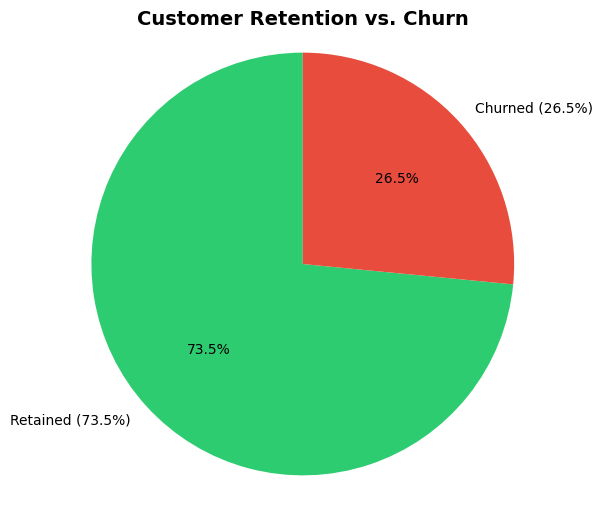

In [3]:
import matplotlib.pyplot as plt

# Example data – replace with your counts
retained = 5174   # non-churned
churned = 1869    # churned

labels = ['Retained (73.5%)', 'Churned (26.5%)']
sizes = [retained, churned]
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Customer Retention vs. Churn', fontsize=14, weight='bold')
plt.axis('equal')
plt.savefig('churn_pie_chart.png', dpi=300)
plt.show()

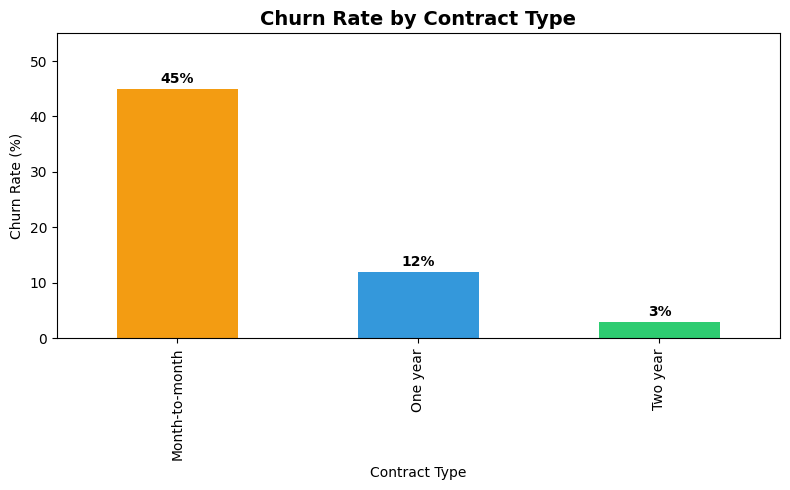

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataframe is 'df'
# contract_churn = df.groupby('Contract')['Churn'].mean() * 100

# Example data – replace with your actual calculation
contract_churn = pd.Series({
    'Month-to-month': 45,
    'One year': 12,
    'Two year': 3
})

plt.figure(figsize=(8,5))
contract_churn.plot(kind='bar', color=['#f39c12', '#3498db', '#2ecc71'])
plt.title('Churn Rate by Contract Type', fontsize=14, weight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 55)
for i, v in enumerate(contract_churn):
    plt.text(i, v + 1, f"{v}%", ha='center', weight='bold')
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=300)
plt.show()

/tmp/ipykernel_667/3315918202.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df,


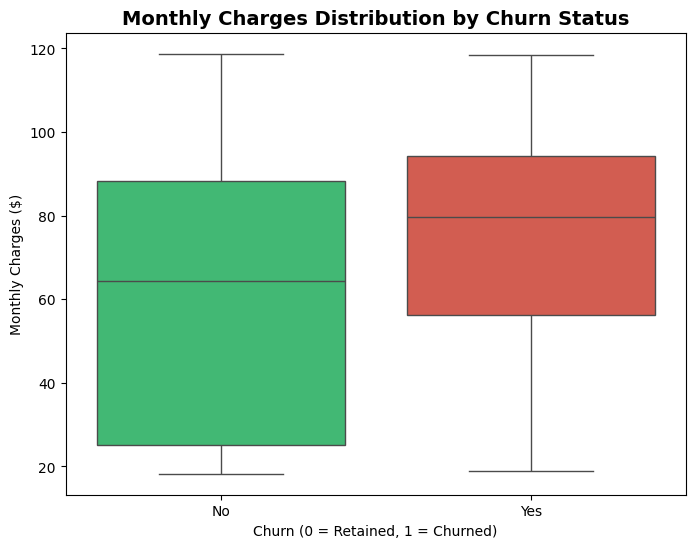

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' has columns 'MonthlyCharges' and 'Churn' (0/1)
# df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges Distribution by Churn Status', fontsize=14, weight='bold')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Monthly Charges ($)')
plt.savefig('monthly_charges_boxplot.png', dpi=300)
plt.show()